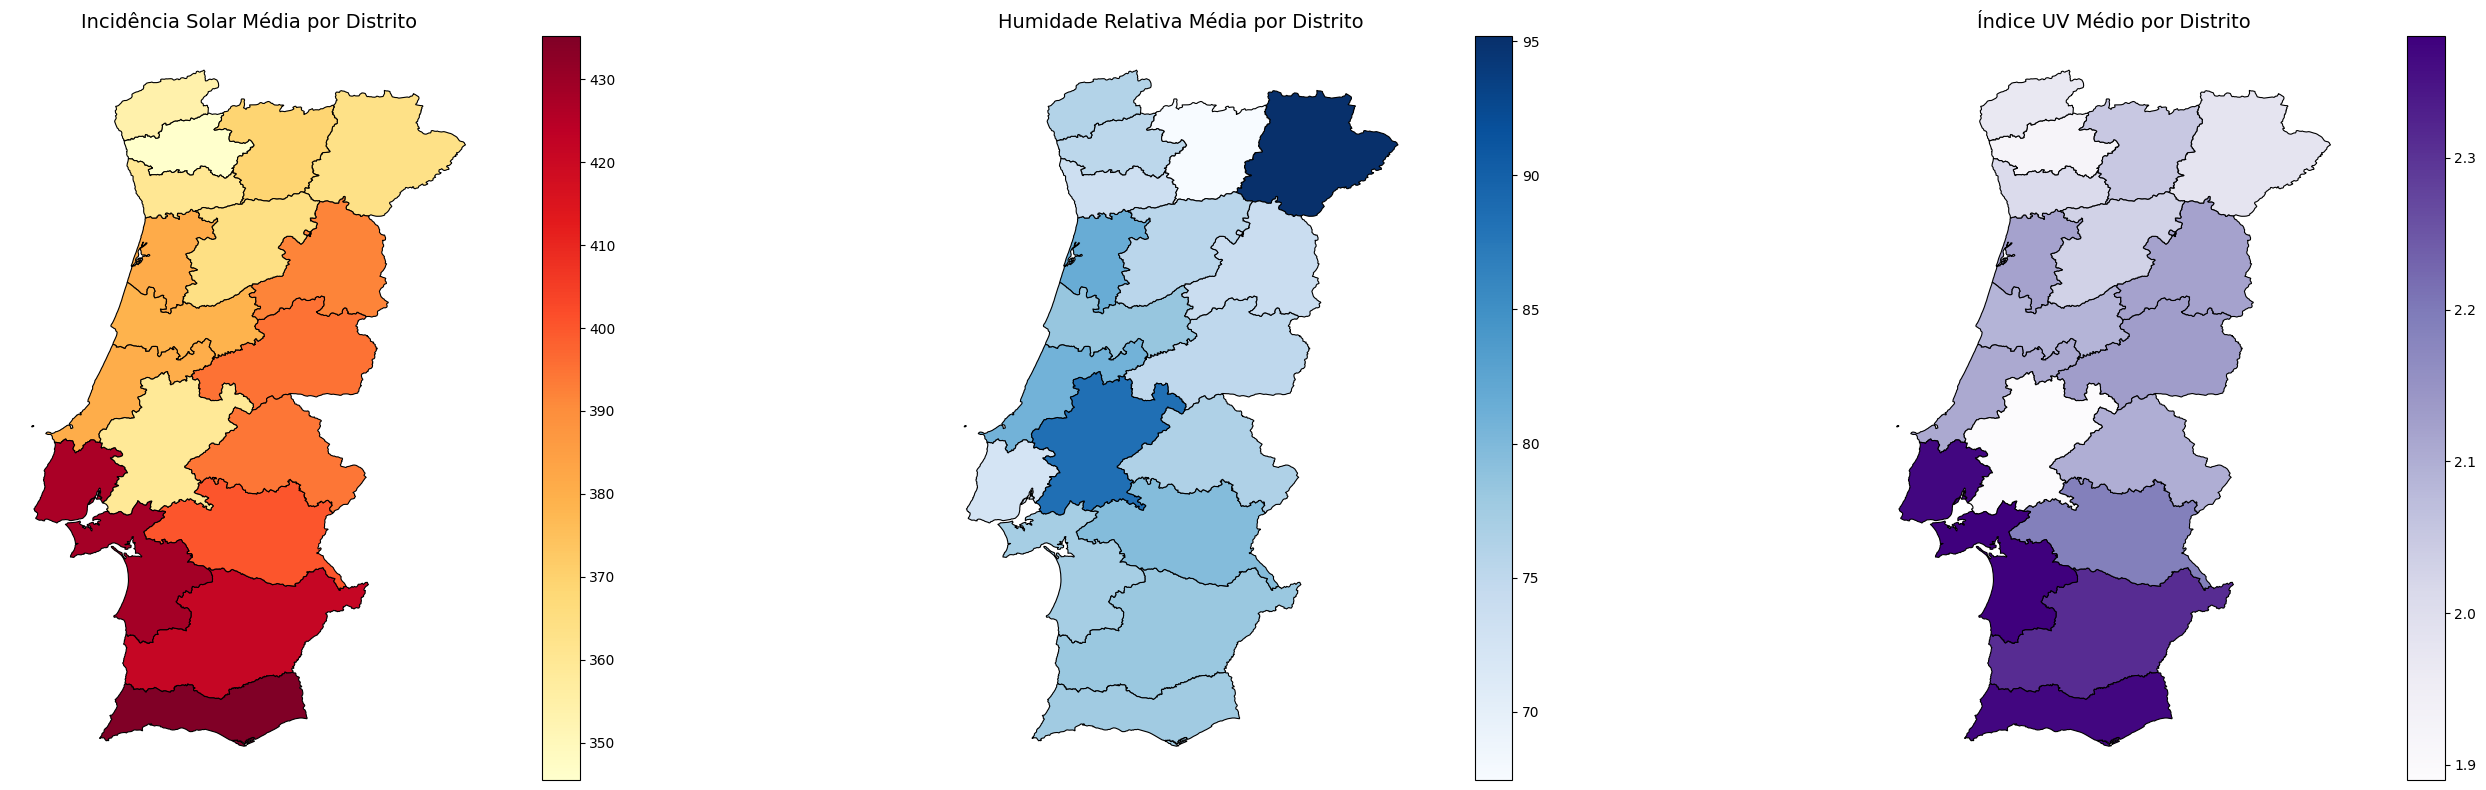

In [18]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib as mpl
import requests
import time

# Configurações das APIs
USERNAME = "leonorsramos"
VISUAL_CROSSING_API_KEY = "JTDSE99F7D9SYSJW2YFQ5EDLG"

# Função para obter dados climáticos de radiação solar, humidade relativa e UV Index
def get_weather_data(district):
    URL_WEATHER = f"https://weather.visualcrossing.com/VisualCrossingWebServices/rest/services/timeline/{district}?key={VISUAL_CROSSING_API_KEY}"
    response = requests.get(URL_WEATHER)
    
    if response.status_code == 200:
        data = response.json()
        
        if "days" in data:
            solar_radiation_values = []
            humidity_values = []
            uv_index_values = []

            for day in data["days"]:
                for hour in day["hours"]:
                    if hour.get("solarradiation") is not None and isinstance(hour["solarradiation"], (int, float)) and hour["solarradiation"] > 0:
                        solar_radiation_values.append(hour["solarradiation"])
                    if hour.get("humidity") is not None and isinstance(hour["humidity"], (int, float)):
                        humidity_values.append(hour["humidity"])
                    if hour.get("uvindex") is not None and isinstance(hour["uvindex"], (int, float)):
                        uv_index_values.append(hour["uvindex"])

            avg_solar_radiation = round(sum(solar_radiation_values) / len(solar_radiation_values), 2) if solar_radiation_values else "N/A"
            avg_humidity = round(sum(humidity_values) / len(humidity_values), 2) if humidity_values else "N/A"
            avg_uv_index = round(sum(uv_index_values) / len(uv_index_values), 2) if uv_index_values else "N/A"
            
            return avg_solar_radiation, avg_humidity, avg_uv_index
        else:
            return "N/A", "N/A", "N/A"
    else:
        return "N/A", "N/A", "N/A"

# Carregar dados dos distritos
dados = pd.read_csv('./data/e-redes_autoconsumo.csv', sep=';')
districts = dados['Distrito'].unique()

# Inicializar lista para armazenar os dados climáticos de todos os distritos
climate_data = {}

# Obter dados para todos os distritos
for district in districts:
    avg_solar_radiation, avg_humidity, avg_uv_index = get_weather_data(district)
    climate_data[district] = {
        "Radiação Solar Média (W/m²)": avg_solar_radiation,
        "Humidade Relativa Média (%)": avg_humidity,
        "Índice UV Médio": avg_uv_index
    }
    time.sleep(1)  # Pausa para evitar bloqueio da API

# Calcular média para Beja se necessário
if "Beja" in districts and "N/A" in climate_data["Beja"].values():
    distritos_ref = ["Faro", "Setúbal", "Évora"]
    valores_validos = {"Radiação Solar Média (W/m²)": [], "Humidade Relativa Média (%)": [], "Índice UV Médio": []}
    
    for ref in distritos_ref:
        if ref in climate_data:
            for key in valores_validos.keys():
                if isinstance(climate_data[ref][key], (int, float)):
                    valores_validos[key].append(climate_data[ref][key])
    
    for key in valores_validos.keys():
        if valores_validos[key]:
            climate_data["Beja"][key] = round(sum(valores_validos[key]) / len(valores_validos[key]), 2)

# Criar DataFrame
df = pd.DataFrame.from_dict(climate_data, orient='index')
df.reset_index(inplace=True)
df.rename(columns={'index': 'Distrito'}, inplace=True)

# Converter colunas para valores numéricos, substituindo 'N/A' por NaN
df["Radiação Solar Média (W/m²)"] = pd.to_numeric(df["Radiação Solar Média (W/m²)"], errors='coerce')
df["Humidade Relativa Média (%)"] = pd.to_numeric(df["Humidade Relativa Média (%)"], errors='coerce')
df["Índice UV Médio"] = pd.to_numeric(df["Índice UV Médio"], errors='coerce')

# Salvar os dados
df.to_csv("dados_climaticos_distritos.csv", index=False, sep=';')

# Carregar o shapefile de Portugal
mapa_pt = gpd.read_file('./pt.json')
if 'NAME_1' in mapa_pt.columns:
    mapa_pt = mapa_pt.rename(columns={'NAME_1': 'Distrito'})

# Criar a figura com três subgráficos lado a lado
fig, axes = plt.subplots(1, 3, figsize=(30, 8))

# Configuração de cores
cmap_solar = mpl.cm.YlOrRd
cmap_humidity = mpl.cm.Blues
cmap_uv = mpl.cm.Purples

# Normalizar valores
norm_solar = mpl.colors.Normalize(vmin=df["Radiação Solar Média (W/m²)"].min(), vmax=df["Radiação Solar Média (W/m²)"].max())
norm_humidity = mpl.colors.Normalize(vmin=df["Humidade Relativa Média (%)"].min(), vmax=df["Humidade Relativa Média (%)"].max())
norm_uv = mpl.colors.Normalize(vmin=df["Índice UV Médio"].min(), vmax=df["Índice UV Médio"].max())

# Função para plotar mapas
def plot_map(ax, data_column, title, cmap, norm):
    mapa_data = mapa_pt.merge(df, on='Distrito', how='left')
    mapa_data.plot(column=data_column, cmap=cmap, linewidth=0.8, edgecolor='black', legend=True, ax=ax, norm=norm)
    ax.set_title(title, fontsize=14)
    ax.set_axis_off()

# Gerar os mapas
plot_map(axes[0], "Radiação Solar Média (W/m²)", "Incidência Solar Média por Distrito", cmap_solar, norm_solar)
plot_map(axes[1], "Humidade Relativa Média (%)", "Humidade Relativa Média por Distrito", cmap_humidity, norm_humidity)
plot_map(axes[2], "Índice UV Médio", "Índice UV Médio por Distrito", cmap_uv, norm_uv)

# Ajustar layout
plt.tight_layout()
plt.show()


Distrito                        object
Radiação Solar Média (W/m²)    float64
Humidade Relativa Média (%)    float64
Índice UV Médio                float64
dtype: object


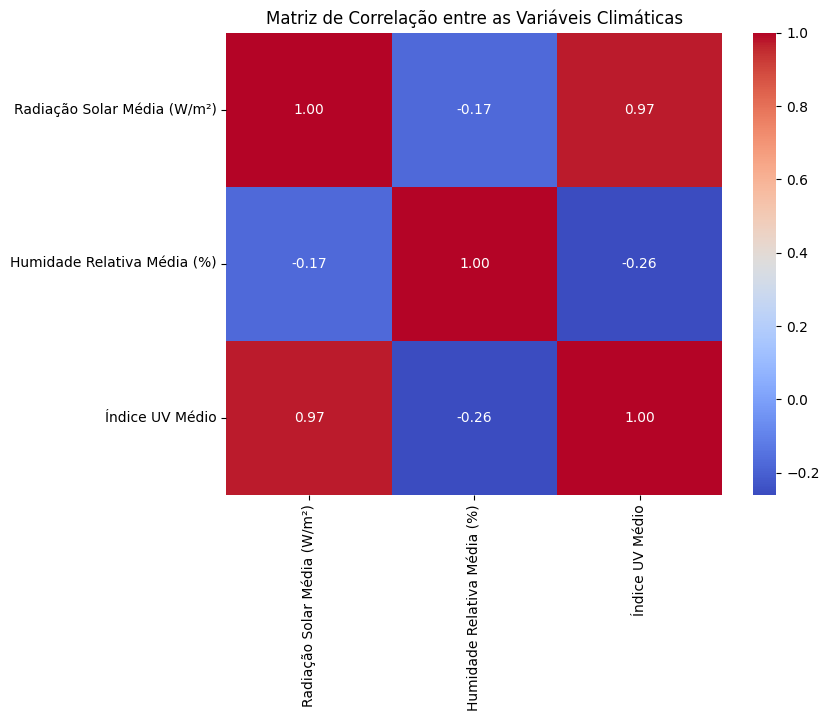

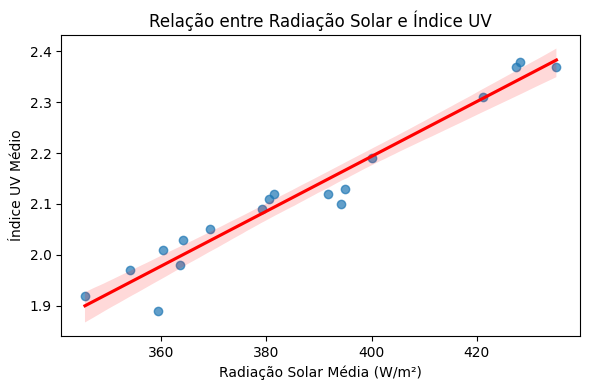

In [29]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Carregar os dados
df = pd.read_csv("dados_climaticos_distritos.csv", sep=';')

# Verificar os tipos de dados das colunas
print(df.dtypes)

# Converter colunas numéricas corretamente (caso tenham sido lidas como strings)
numeric_columns = ["Radiação Solar Média (W/m²)", "Humidade Relativa Média (%)", "Índice UV Médio"]
df[numeric_columns] = df[numeric_columns].apply(pd.to_numeric, errors="coerce")

# Remover colunas não numéricas e lidar com valores NaN
df_numeric = df[numeric_columns].dropna()

# Criar a matriz de correlação
correlation_matrix = df_numeric.corr()

# Plotar a matriz de correlação
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Matriz de Correlação entre as Variáveis Climáticas")
plt.show()

# Criar o gráfico de dispersão entre Radiação Solar e Índice UV com linha de tendência
plt.figure(figsize=(6, 4))
sns.regplot(x=df_numeric["Radiação Solar Média (W/m²)"], y=df_numeric["Índice UV Médio"], scatter_kws={"alpha": 0.7}, line_kws={"color": "red"})
plt.title("Relação entre Radiação Solar e Índice UV")
plt.tight_layout()
plt.show()
